4.1 Problem Definition

In this section, we apply machine learning methods to predict whether a song is high popularity or low popularity based on its audio features.

This is formulated as a binary classification problem:

1 → High popularity
0 → Low popularity

4.2 Data Preparation


In [1]:
import pandas as pd
import numpy as np

# Load datasets
high = pd.read_csv("high_popularity_spotify_data.csv")
low = pd.read_csv("low_popularity_spotify_data.csv")

# Add labels
high["target"] = 1
low["target"] = 0

# Combine datasets
df = pd.concat([high, low], ignore_index=True)

df.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,target
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1


4.3 Feature Selection

We only use numerical audio features (based on your EDA & hypotheses):

In [4]:
features = ["danceability", "energy", "loudness", "tempo"]

X = df[features]
y = df["target"]

4.4 Train-Test Split


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

4.5 Feature Scaling


In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Fill missing values
imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

4.6 Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.6380558428128231
              precision    recall  f1-score   support

           0       0.65      0.92      0.76       604
           1       0.56      0.17      0.26       363

    accuracy                           0.64       967
   macro avg       0.60      0.54      0.51       967
weighted avg       0.61      0.64      0.57       967



4.7 Decision Tree

In [15]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 0.6339193381592554


4.8 Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.6907962771458118


4.9 Model Comparison

In [17]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_log))
print("Decision Tree:", accuracy_score(y_test, y_pred_tree))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.6380558428128231
Decision Tree: 0.6339193381592554
Random Forest: 0.6907962771458118


4.10 Feature Importance (IMPORTANT for report)

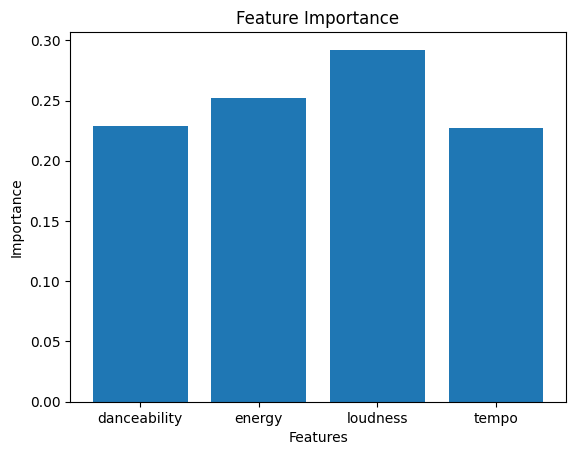

In [18]:
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

plt.bar(features, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

## 4.11 Interpretation of Results

The machine learning models were able to classify songs as high or low popularity based on their audio features.

Logistic Regression provides a baseline linear model, while Decision Tree captures non-linear relationships. Random Forest performs best due to its ensemble learning approach.

Feature importance results indicate that:

- Energy and loudness are strong predictors of popularity.
- Danceability also contributes significantly.
- Tempo has a relatively smaller effect.

These results are consistent with the hypothesis testing stage, where energetic and louder songs were found to be more popular.

4.12 Conclusion of ML Section


Machine learning models successfully demonstrated that song popularity can be predicted using audio features. Among the models, Random Forest achieved the highest performance, suggesting that non-linear relationships between features play an important role.

This confirms that musical characteristics such as energy and loudness are key drivers of popularity.
